# Gerchberg-Saxton phase retrieval

In this tutorial, we retrieve the phase of a laser pulse from measurements of the intensity at different planes. The number of planes should be greater than or equal to two. The phase retrieval can either be done using a modal decomposition or any propagator of choice. 

In [1]:
from copy import deepcopy

import matplotlib.pyplot as plt
import numpy as np
from scipy.constants import c, epsilon_0

from lasy.laser import Laser
from lasy.profiles import CombinedLongitudinalTransverseProfile
from lasy.profiles.longitudinal import ContinuousWaveProfile
from lasy.profiles.transverse import (
    GaussianTransverseProfile
)

from lasy.optical_elements import Axiparabola, ParabolicMirror
from lasy.propagators import ABCD, CollinsSFFTPropagator

from lasy.utils.mode_decomposition import *
from lasy.utils.phase_retrieval import GerchbergSaxton

Next, we define the beam to be CW with a tophat profile in the transverse plane:

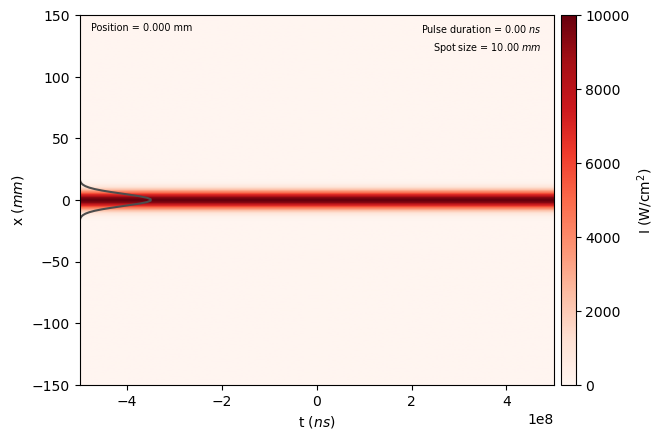

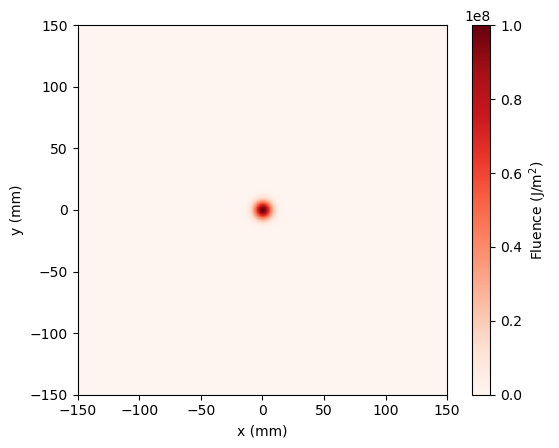

In [2]:
peak_fluence = 1.0e8  # J/m^2
spot_size = 10e-3
wavelength = 800e-9
omega0 = 2 * np.pi * c / wavelength
pol = (1, 0)

dimensions = "xyt"  # Use cylindrical geometry
lo = (-15.0 * spot_size, -15.0 * spot_size, None)  # Lower bounds of the simulation box
hi = (15.0 * spot_size, 15.0 * spot_size, None)  # Upper bounds of the simulation box
num_points = (256, 256, 1)  # Number of points in each dimension

long_prof = ContinuousWaveProfile(wavelength)
tran_prof = GaussianTransverseProfile(spot_size)
laser_profile = CombinedLongitudinalTransverseProfile(
    wavelength, pol, long_prof, tran_prof, peak_fluence=peak_fluence
)

laser = Laser(dimensions, lo, hi, num_points, laser_profile)

# Plot the xt laser profile
laser.show(envelope_type="intensity")  # In this case this is the fluence (CW beam)

# Plot the transverse laser profile
intensity = epsilon_0 * c / 2 * np.abs(laser.grid.get_temporal_field()) ** 2
fluence = np.sum(intensity, axis=-1).T * laser.grid.dx[-1]
extent = (
    laser.grid.axes[0].min() * 1e3,
    laser.grid.axes[0].max() * 1e3,
    laser.grid.axes[1].min() * 1e3,
    laser.grid.axes[1].max() * 1e3,
)
plt.figure()
plt.imshow(fluence, extent=extent, cmap="Reds")
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.colorbar(label=r"Fluence (J/m$^2$)")

In [3]:
# Modal coefficients used to construct the beam
modes = {}
modes[(0, 0)] = 1 - 0.2j
modes[(0, 1)] = -0.4 - 0.2j
modes[(1, 0)] = 0.5 + 1j
modes[(2, 2)] = -0.05 + 0.1j

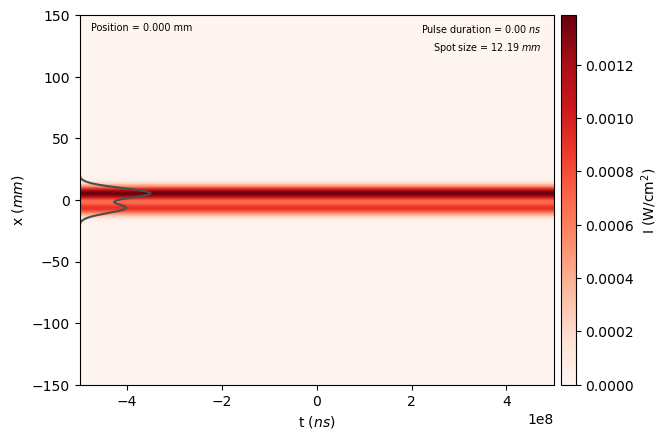

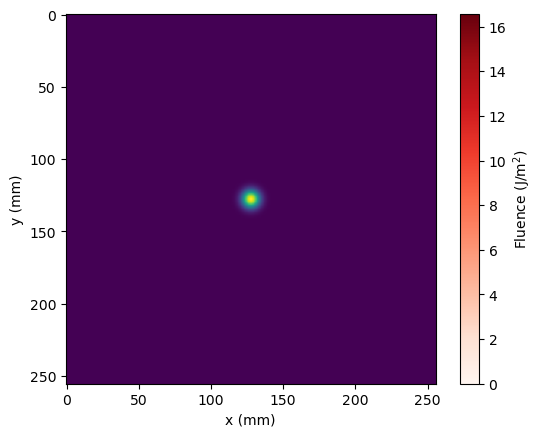

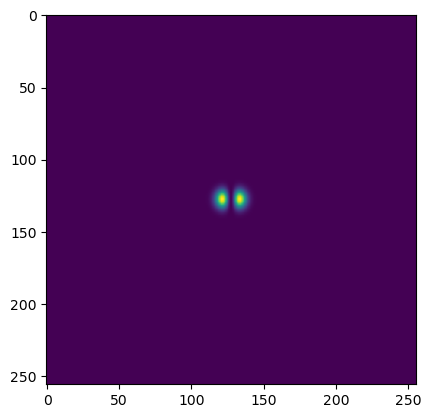

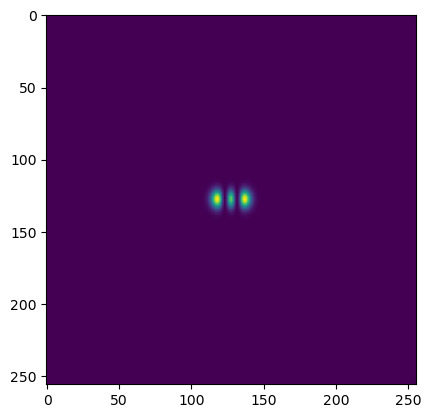

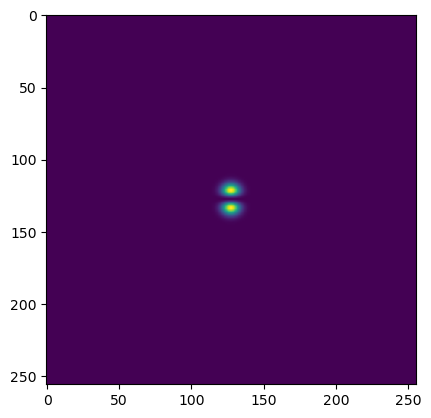

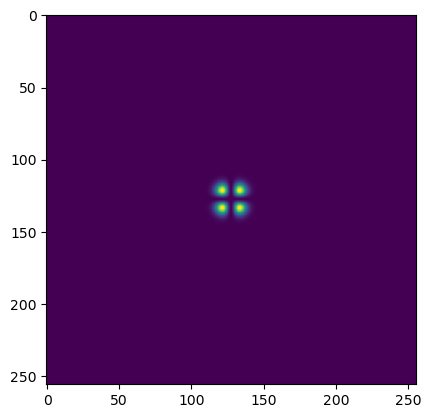

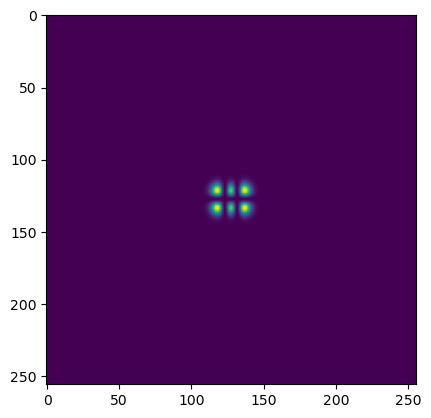

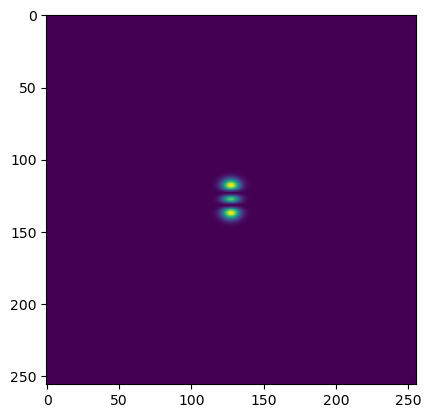

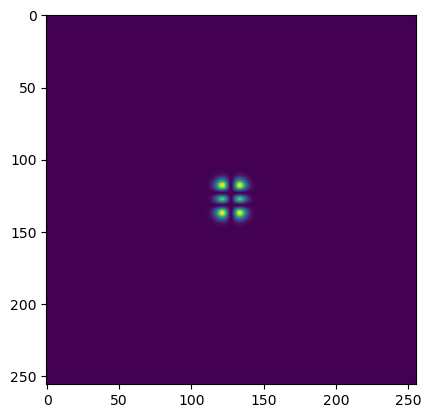

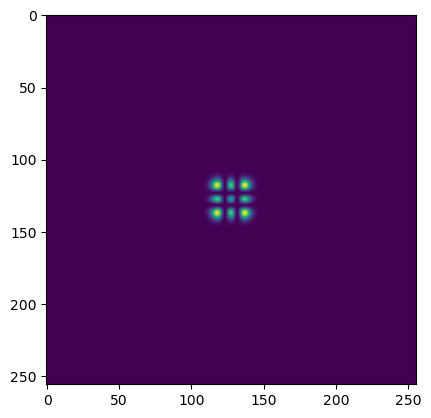

Mode coefficients for HG beam (up to third order)
0,0 :  1.00  ,  -0.20 i
0,1 :  -0.40  ,  -0.20 i
0,2 :  0.00  ,  -0.00 i
1,0 :  0.50  ,  1.00 i
1,1 :  0.00  ,  -0.00 i
1,2 :  0.00  ,  0.00 i
2,0 :  0.00  ,  0.00 i
2,1 :  -0.00  ,  -0.00 i
2,2 :  -0.05  ,  0.10 i


In [4]:
HG_laser = deepcopy(laser)  # Make a copy of the input grid
hermite_gauss_composition(
    HG_laser, spot_size, spot_size, modes, skipAsymmetricModes=False
)

HG_laser.show(envelope_type="intensity")  # In this case this is the fluence (CW beam)

intensity = epsilon_0 * c / 2 * np.abs(HG_laser.grid.get_temporal_field()) ** 2
fluence = np.sum(intensity, axis=-1).T * HG_laser.grid.dx[-1]
extent = (
    HG_laser.grid.axes[0].min() * 1e3,
    HG_laser.grid.axes[0].max() * 1e3,
    HG_laser.grid.axes[1].min() * 1e3,
    HG_laser.grid.axes[1].max() * 1e3,
)
plt.figure()
plt.imshow(fluence, extent=extent, cmap="Reds")
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.colorbar(label=r"Fluence (J/m$^2$)")

calculatedModes = hermite_gauss_decomposition(HG_laser, spot_size, spot_size, 3, 3)
print("Mode coefficients for HG beam (up to third order)")
for calcModeKey in calculatedModes.keys():
    print(
        "%i,%i :  %.2f  ,  %.2f i"
        % (
            calcModeKey[0],
            calcModeKey[1],
            np.real(calculatedModes[calcModeKey]),
            np.imag(calculatedModes[calcModeKey]),
        )
    )

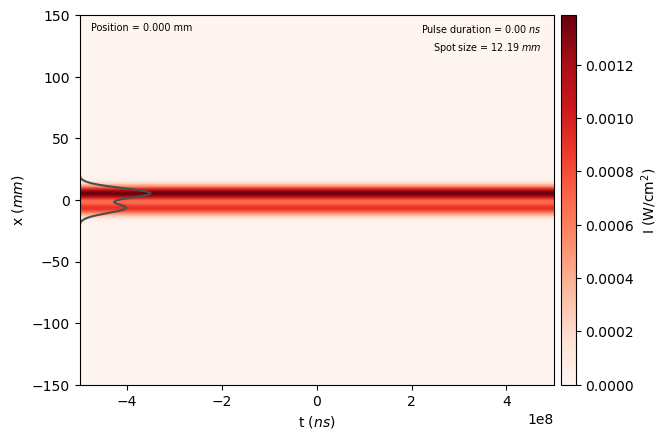

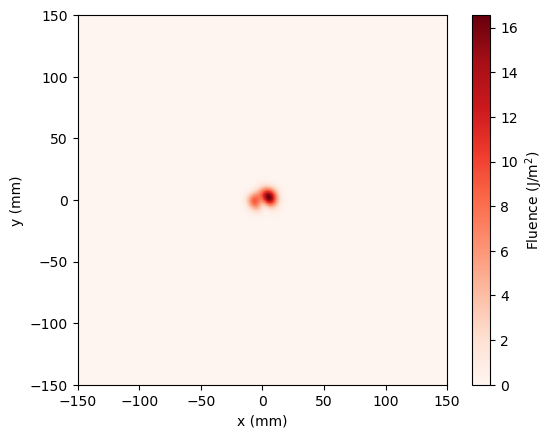

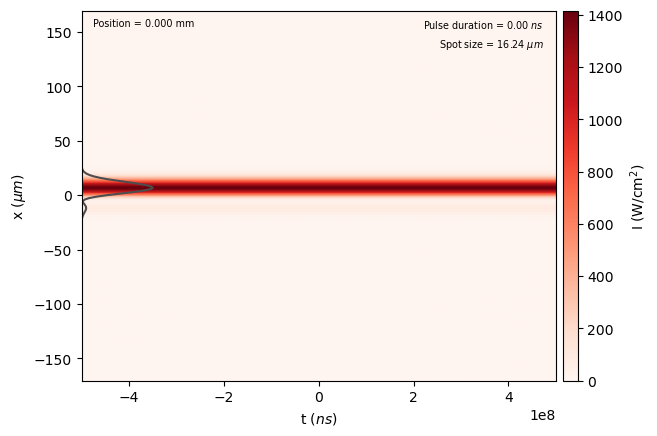

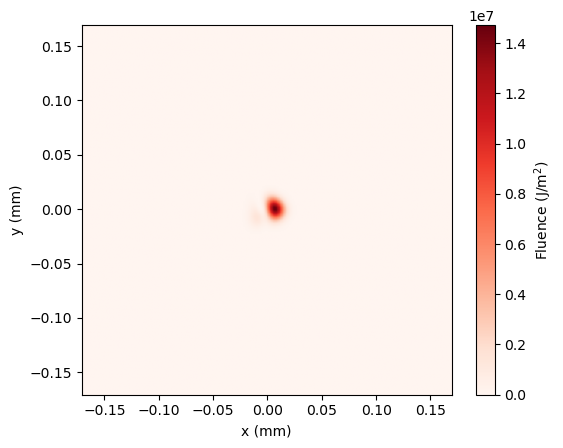

In [5]:
plane1 = deepcopy(HG_laser)  # This is the field immediately prior to the lens
plane2 = deepcopy(HG_laser)  # This will be the field at focus

f0 = 500e-3

prop = CollinsSFFTPropagator(dimensions, omega0)
abcd = ABCD()
abcd.add_lens(f0)
abcd.add_vacuum(f0)
prop.propagate(plane2.grid, abcd)

# Create instances of the propagator and ABCD matrix
plane1.show(envelope_type="intensity")  # In this case this is the fluence (CW beam)

intensity = epsilon_0 * c / 2 * np.abs(plane1.grid.get_temporal_field()) ** 2
fluence = np.sum(intensity, axis=-1).T * plane1.grid.dx[-1]
extent = (
    plane1.grid.axes[0].min() * 1e3,
    plane1.grid.axes[0].max() * 1e3,
    plane1.grid.axes[1].min() * 1e3,
    plane1.grid.axes[1].max() * 1e3,
)
plt.figure()
plt.imshow(fluence, extent=extent, cmap="Reds")
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.colorbar(label=r"Fluence (J/m$^2$)")


plane2.show(envelope_type="intensity")  # In this case this is the fluence (CW beam)

intensity = epsilon_0 * c / 2 * np.abs(plane2.grid.get_temporal_field()) ** 2
fluence = np.sum(intensity, axis=-1).T * plane2.grid.dx[-1]
extent = (
    plane2.grid.axes[0].min() * 1e3,
    plane2.grid.axes[0].max() * 1e3,
    plane2.grid.axes[1].min() * 1e3,
    plane2.grid.axes[1].max() * 1e3,
)
plt.figure()
plt.imshow(fluence, extent=extent, cmap="Reds")
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.colorbar(label=r"Fluence (J/m$^2$)")
plt.show()

Estimated w0(x-axis) = 15.69 microns (1/e^2 width)
Estimated w0(y-axis) = 16.48 microns (1/e^2 width)


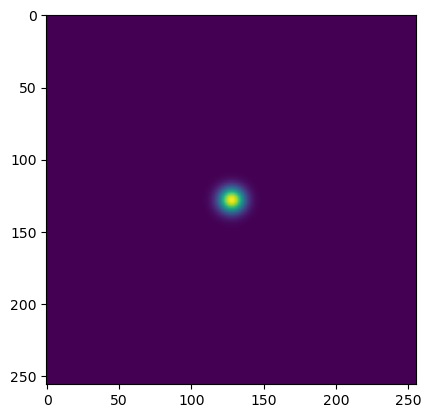

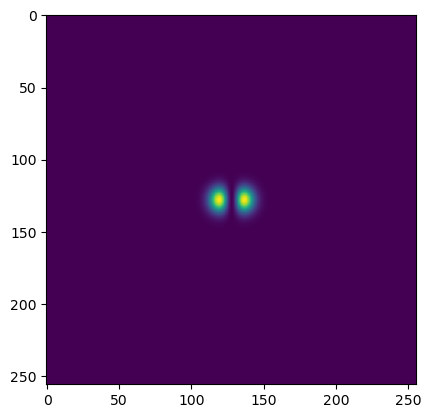

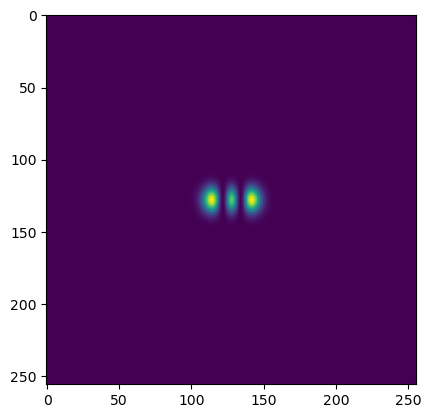

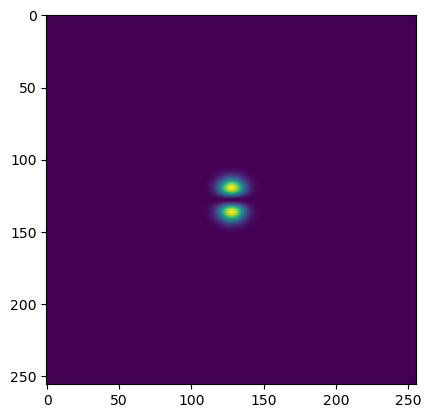

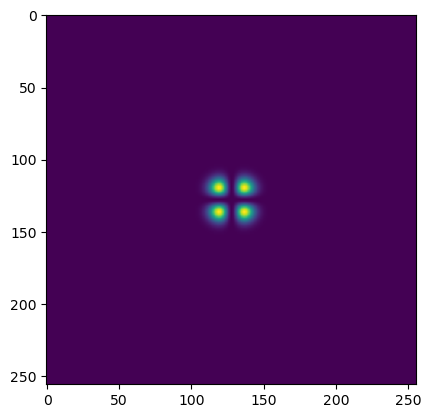

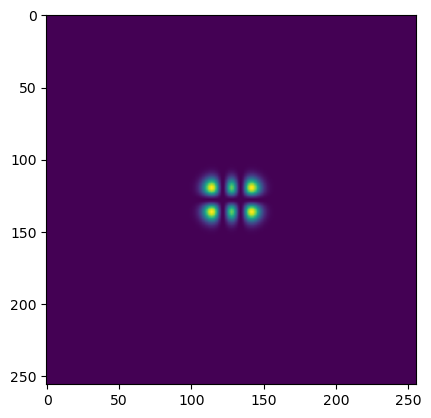

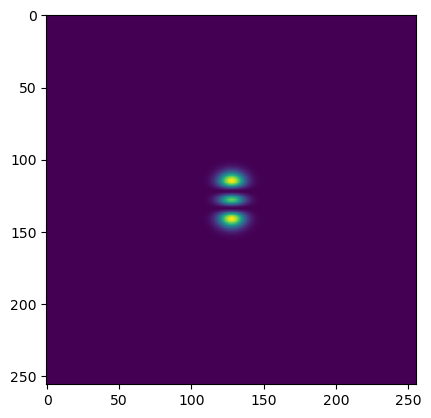

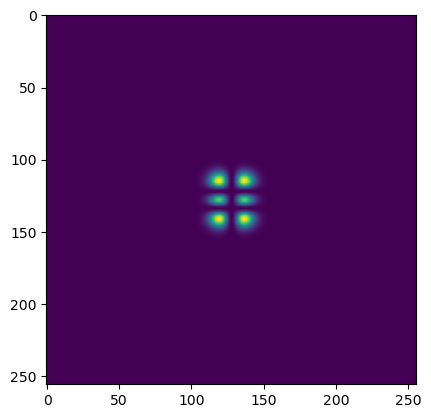

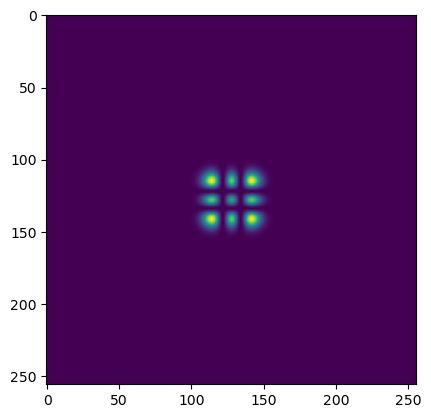

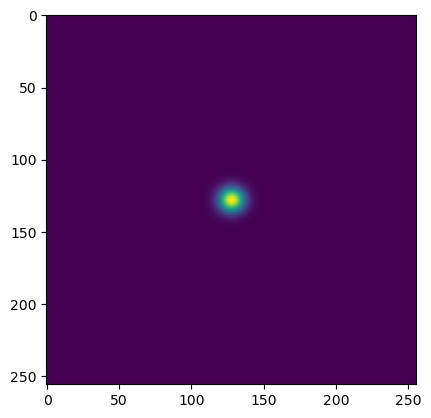

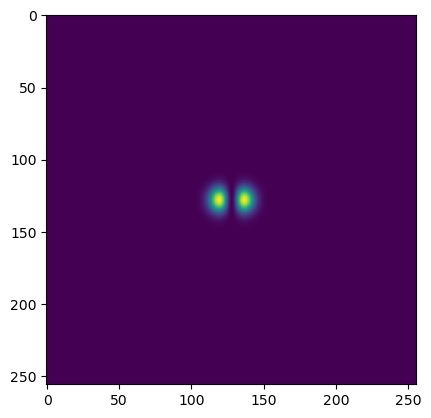

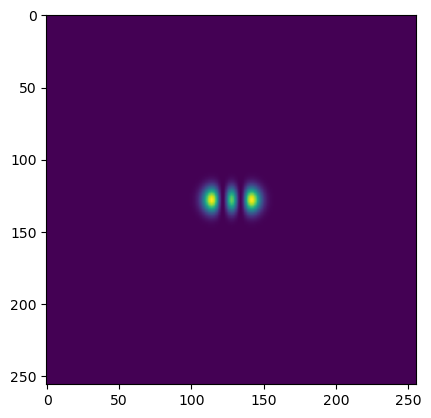

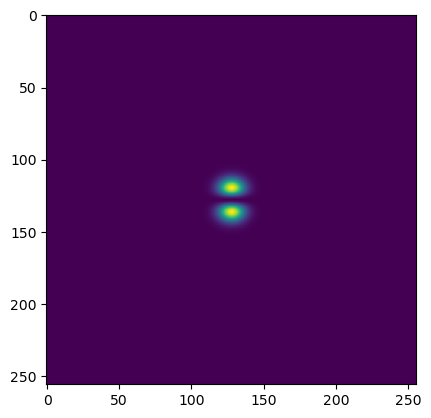

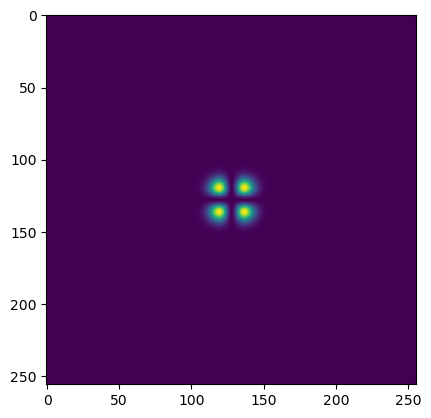

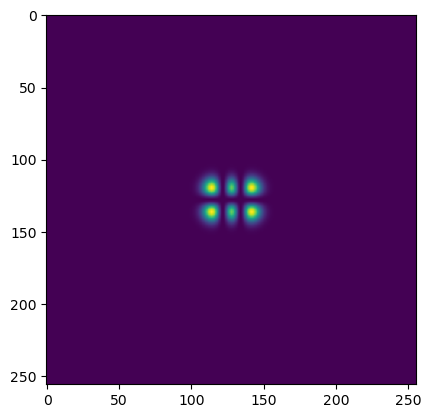

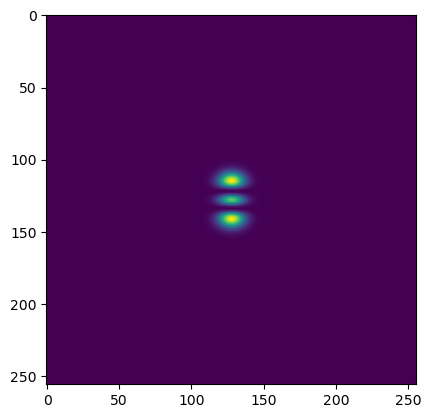

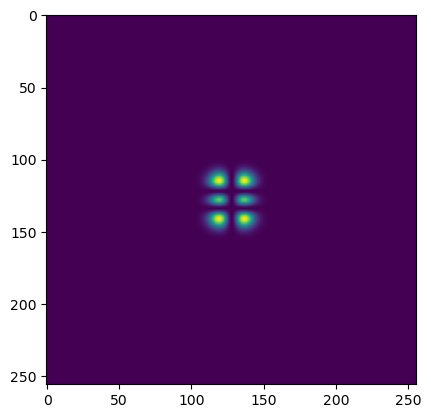

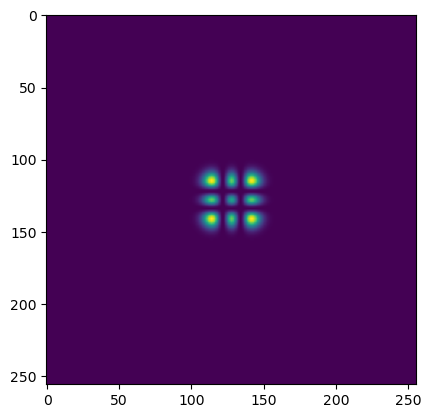

Mode coefficients for HG beam (up to third order)
0,0 :  5.28e-18  ,  -6.17e-18 i
0,1 :  -1.42e-17  ,  -8.90e-18 i
0,2 :  2.29e-18  ,  -6.88e-18 i
1,0 :  5.51e-18  ,  2.74e-18 i
1,1 :  -2.74e-18  ,  -5.86e-18 i
1,2 :  -1.95e-18  ,  6.17e-18 i
2,0 :  7.11e-20  ,  -3.76e-18 i
2,1 :  1.53e-19  ,  -1.64e-18 i
2,2 :  -2.44e-18  ,  2.42e-18 i
Initial estimate of mode coefficients:
0,0 :  5.12e-18  ,  -1.26e-17 i
0,1 :  -5.87e-18  ,  7.61e-18 i
0,2 :  6.68e-18  ,  1.48e-18 i
1,0 :  -2.72e-18  ,  5.04e-18 i
1,1 :  2.77e-18  ,  -9.91e-18 i
1,2 :  -1.79e-18  ,  6.31e-18 i
2,0 :  -2.51e-18  ,  8.04e-20 i
2,1 :  9.55e-19  ,  5.06e-19 i
2,2 :  -1.32e-18  ,  -1.42e-19 i


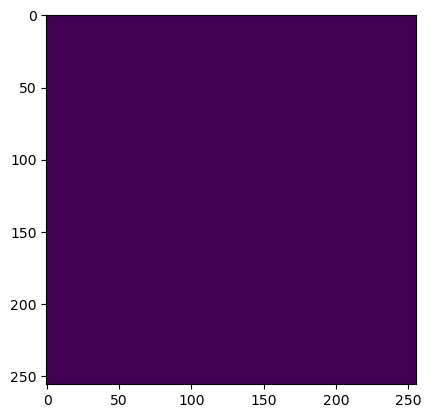

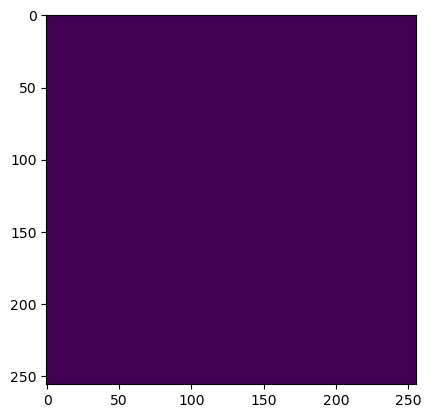

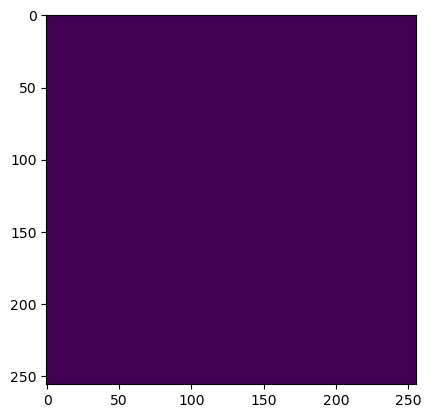

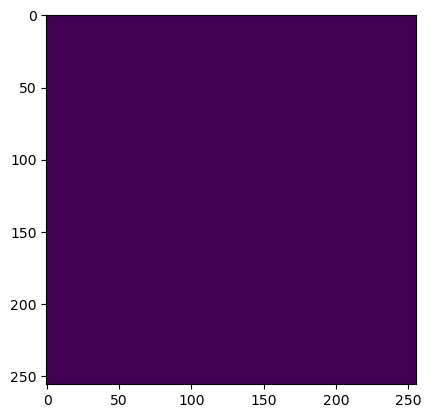

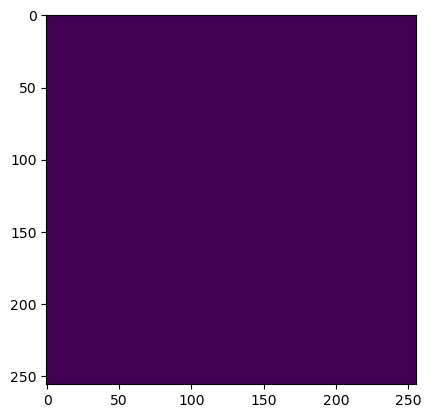

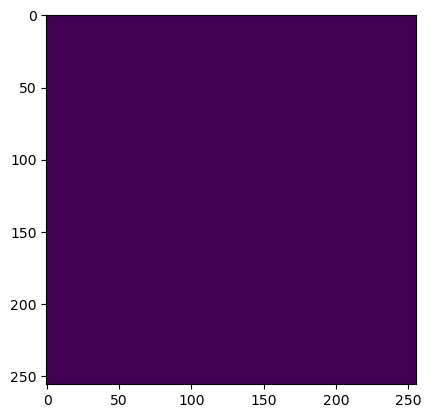

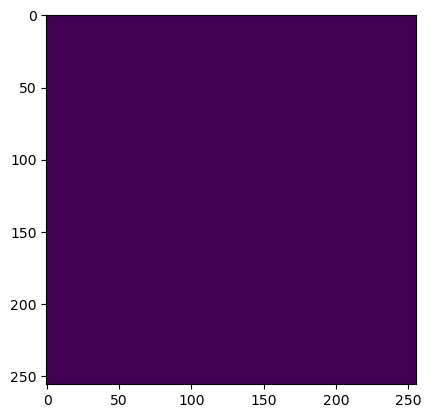

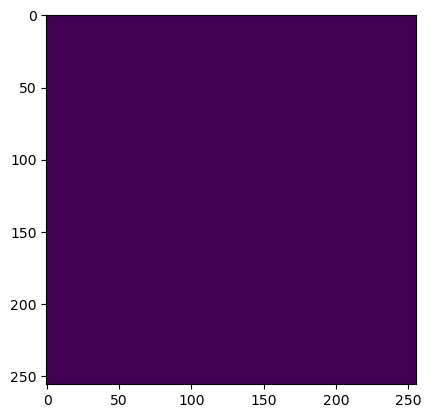

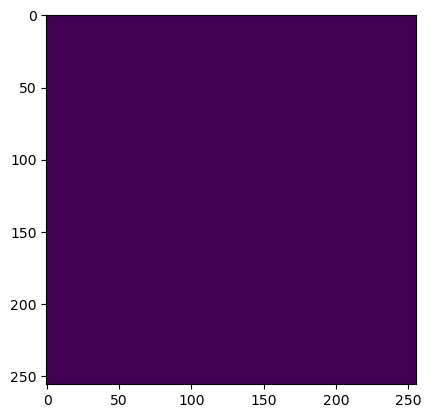

NameError: name 'dz' is not defined

In [6]:
gs = GerchbergSaxton([plane1,plane2], [0, f0], m_max=3, n_max=3, max_iter=2000)


calculatedModes = hermite_gauss_decomposition(plane2, 15.69e-6, 16.48e-6, 3, 3)
print("Mode coefficients for HG beam (up to third order)")
for calcModeKey in calculatedModes.keys():
    print(
        "%i,%i :  %.2e  ,  %.2e i"
        % (
            calcModeKey[0],
            calcModeKey[1],
            np.real(calculatedModes[calcModeKey]),
            np.imag(calculatedModes[calcModeKey]),
        )
    )
    
print("Initial estimate of mode coefficients:")
for mode in gs.modes.keys():
    print(
        "%i,%i :  %.2e  ,  %.2e i"
        % (
            mode[0],
            mode[1],
            np.real(gs.modes[mode]),
            np.imag(gs.modes[mode]),
        )
    )

phase1, phase2, errors = gs.retrieve_phase()

In [ ]:
plt.figure()
plt.imshow(np.angle(laser.grid.get_temporal_field())/(np.pi), extent=extent, cmap="YlGnBu")
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.colorbar(label=r"Angle ($\pi$)")
plt.show()

from unwrap import unwrap
plt.figure()
plt.imshow(phase1/(np.pi), extent=extent, cmap="YlGnBu")
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.colorbar(label=r"Angle ($\pi$)")
plt.show()

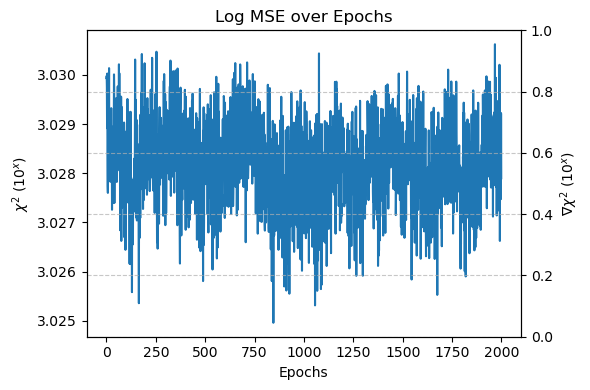

In [8]:
# Plot training and validation log MSE with 10^x format for the y-axis
def plot_log_mse(chi2):
    """
    Plots the logarithm (base 10) of training and validation MSE losses with 10^x format for the y-axis.

    Parameters:
        train_losses (list): Training MSE values over epochs.
        val_losses (list): Validation MSE values over epochs.
    """
    fig, ax1 = plt.subplots(figsize=(6, 4))
    ax2 = ax1.twinx()
    log_chi2 = np.log10(chi2+1e-8)
    
    ax1.plot(range(len(chi2)),log_chi2)
    # ax2.plot(range(len(chi2)),gradchi2, '--')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel(r'$\chi^2$ ($10^x$)')
    ax2.set_ylabel(r'$\nabla \chi^2$ ($10^x$)')
    plt.title('Log MSE over Epochs')
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # Customize the y-axis ticks to show as 10^x
    # y_ticks = np.arange(int(np.floor(min(log_chi2.min(), log_chi2.min()))), 
    #                     int(np.ceil(max(log_chi2.max(), log_chi2.max()))) + 1)
    # ax1.set_yticks(y_ticks)
    # ax1.set_yticklabels([r"$10^{{{}}}$".format(int(tick)) for tick in y_ticks])
    
    plt.tight_layout()
    plt.show()
plot_log_mse(errors)